In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

In [2]:
# 预训练模型用 ImageNet 的归一化参数，图片统一缩放到 224x224
IMG_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE, padding=8),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25),
])

transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [3]:
batch_size = 128

trainset = torchvision.datasets.CIFAR10(
    root='./data/cifar-10-python', train=True, download=False, transform=transform_train
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True
)

testset = torchvision.datasets.CIFAR10(
    root='./data/cifar-10-python', train=False, download=False, transform=transform_test
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True
)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

In [4]:
# 迁移学习：ImageNet 预训练的 ResNet18，替换最后一层为 10 类
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 10)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 标签平滑 + 余弦退火学习率
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    loop = tqdm(loader, desc='Training', mininterval=1.0)  # 每秒最多刷一次进度条，减少显示开销
    for inputs, targets in loop:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        # bf16 混合精度：RTX 50 系实测提速约 65%（不影响准确率）
        with torch.autocast('cuda', dtype=torch.bfloat16):
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
    return running_loss / len(loader), 100.*correct/total

In [7]:
def test(model, loader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in tqdm(loader, desc='Testing', mininterval=1.0):
            inputs, targets = inputs.to(device), targets.to(device)
            with torch.autocast('cuda', dtype=torch.bfloat16):
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return test_loss / len(loader), 100.*correct/total

In [8]:
num_epochs = 10
best_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, trainloader, criterion, optimizer)
    val_loss, val_acc = test(model, testloader, criterion)
    scheduler.step()

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_model_resnet18.pth')

    print(f'Epoch {epoch+1:02d}: Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.2f}% | Best: {best_acc:.2f}%')

print('Finished Training!')

Testing: 100%|██████████| 79/79 [00:17<00:00,  4.59it/s]


Epoch 01: Train Loss: 0.921 | Train Acc: 83.55% | Val Loss: 0.719 | Val Acc: 92.91% | Best: 92.91%


Testing: 100%|██████████| 79/79 [00:03<00:00, 19.92it/s]


Epoch 02: Train Loss: 0.735 | Train Acc: 92.01% | Val Loss: 0.691 | Val Acc: 93.35% | Best: 93.35%


Testing: 100%|██████████| 79/79 [00:03<00:00, 19.96it/s]


...

Epoch 08: Train Loss: 0.604 | Train Acc: 97.28% | Val Loss: 0.645 | Val Acc: 95.30% | Best: 95.69%


Testing: 100%|██████████| 79/79 [00:06<00:00, 12.02it/s]


Epoch 09: Train Loss: 0.598 | Train Acc: 97.57% | Val Loss: 0.636 | Val Acc: 95.60% | Best: 95.69%


Testing: 100%|██████████| 79/79 [00:04<00:00, 18.96it/s]

Epoch 10: Train Loss: 0.587 | Train Acc: 97.92% | Val Loss: 0.621 | Val Acc: 95.69% | Best: 95.69%
Finished Training!


共找到 6 张图片
15020C406-1.jpg -> 预测类别：plane（置信度 97.45%）


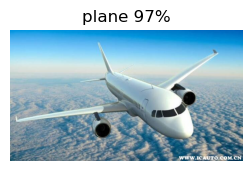

ODL.jpg -> 预测类别：dog（置信度 81.13%）


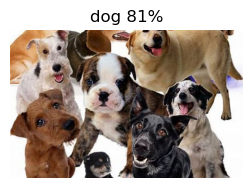

cf1b9d16fdfaaf51f3dec5bd8a0283eef01f3a29cc21.jpg -> 预测类别：cat（置信度 93.39%）


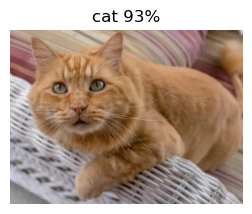

航母1.jpg -> 预测类别：plane（置信度 53.79%）


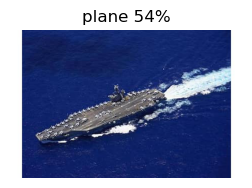

船1.jpg -> 预测类别：bird（置信度 68.78%）


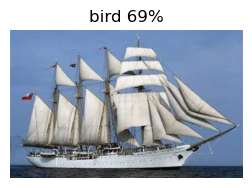

鸟1.jpg -> 预测类别：bird（置信度 91.90%）


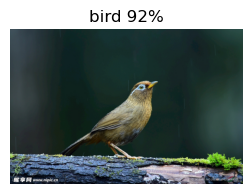

In [14]:
from PIL import Image
import glob, os
import matplotlib.pyplot as plt

# 加载迁移学习模型（结构必须与训练时一致）
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)
model.load_state_dict(torch.load('best_model_resnet18.pth'))
model = model.to(device)
model.eval()

# 预测预处理与训练一致：224x224 + ImageNet 归一化
predict_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

image_dir = 'test_images'
image_files = sorted(
    glob.glob(os.path.join(image_dir, '*.jpg')) +
    glob.glob(os.path.join(image_dir, '*.jpeg')) +
    glob.glob(os.path.join(image_dir, '*.png'))
)
print(f'共找到 {len(image_files)} 张图片')

for img_path in image_files:
    image = Image.open(img_path).convert('RGB')
    x = predict_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(x)
        prob = torch.softmax(output, dim=1)[0]
        pred = output.argmax(1).item()
    print(f'{os.path.basename(img_path)} -> 预测类别：{classes[pred]}（置信度 {prob[pred].item():.2%}）')
    plt.figure(figsize=(3, 3))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'{classes[pred]} {prob[pred].item():.0%}')
    plt.show()